<a href="https://colab.research.google.com/github/cmunozr/2026_I_AI_GU/blob/main/Exercises/ex2_part1_species_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NGEO316 – Exercise: Convolutional Neural Networks Demonstration
## Part 1: Species Classification (Tomato vs Potato vs Apple vs Grape)

**Course:** AI for Earth and Environmental Sciences  
**University of Gothenburg / Chalmers**

---

### What you will do in this lab

You will train a CNN to classify leaf images from the **PlantVillage** dataset into four plant species:
- 🍅 Tomato
- 🥔 Potato
- 🍎 Apple
- 🍇 Grape
- I added Corn (2026-04-14)

The model must learn to distinguish species purely from leaf shape, texture, and colours.

---

> ⚠️ **Enable GPU before starting:** Go to **Runtime → Change runtime type → T4 GPU**.  
> Training will be roughly 10x faster with a GPU.

---

## Step 0 – Install and import libraries

We use:
- **TensorFlow / Keras** – building and training the CNN
- **TensorFlow Datasets (TFDS)** – downloading PlantVillage automatically
- **Matplotlib** – plotting images and training curves
- **scikit-learn** – computing the confusion matrix

In [1]:
# Install/upgrade TensorFlow Datasets (already on Colab — this ensures PlantVillage builder is available)
!pip install -q tensorflow-datasets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print('TensorFlow version:', tf.__version__)
print('GPU available    :', len(tf.config.list_physical_devices('GPU')) > 0)

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
GPU available    : True


---
## Step 1 – Load the PlantVillage dataset

PlantVillage contains ca **55,000 leaf images** across 38 classes (14 plant species x disease types + healthy).  
TFDS downloads and caches it automatically — this takes a few minutes the first time.

In [3]:
ds_full, info = tfds.load(
    'plant_village',
    split='train',        # PlantVillage ships as a single split; we make our own val split below
    with_info=True,
    as_supervised=True,   # returns (image, label) tuples
    shuffle_files=False,
)

CLASS_NAMES = info.features['label'].names

print(f"Total images : {info.splits['train'].num_examples:,}")
print(f"Total classes: {info.features['label'].num_classes}")
print()
print('All class names:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i:2d}] {name}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.58NVPE_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Total images : 54,303
Total classes: 38

All class names:
  [ 0] Apple___Apple_scab
  [ 1] Apple___Black_rot
  [ 2] Apple___Cedar_apple_rust
  [ 3] Apple___healthy
  [ 4] Blueberry___healthy
  [ 5] Cherry___healthy
  [ 6] Cherry___Powdery_mildew
  [ 7] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [ 8] Corn___Common_rust
  [ 9] Corn___healthy
  [10] Corn___Northern_Leaf_Blight
  [11] Grape___Black_rot
  [12] Grape___Esca_(Black_Measles)
  [13] Grape___healthy
  [14] Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  [15] Orange___Haunglongbing_(Citrus_greening)
  [16] Peach___Bacterial_spot
  [17] Peach___healthy
  [18] Pepper,_bell___Bacterial_spot
  [19] Pepper,_bell___healthy
  [20] Potato___Early_blight
  [21] Potato___healthy
  [22] Potato___Late_blight
  [23] Raspberry___healthy
  [24] Soybean___healthy
  [25] Squash___Powdery_mildew
  [26] Strawberry___

### Identify the classes we need

We want only the **healthy** images for tomato, potato, and grape.  
Find the indices for `Tomato___healthy`, `Potato___healthy`, and `Grape___healthy` in the list above.

In [8]:
def find_label_index(keyword_list):
    """Return (index, name) for all classes matching ALL given keywords."""
    return [
        (i, name) for i, name in enumerate(CLASS_NAMES)
        if all(kw.lower() in name.lower() for kw in keyword_list)
    ]

tomato_healthy = find_label_index(['tomato', 'healthy'])
potato_healthy = find_label_index(['potato', 'healthy'])
apple_healthy  = find_label_index(['apple',  'healthy'])
grape_healthy  = find_label_index(['grape',  'healthy'])
corn_healthy = find_label_index(['corn',  'healthy'])

print('Tomato healthy:', tomato_healthy)
print('Potato healthy:', potato_healthy)
print('Apple healthy :', apple_healthy)
print('Grape healthy :', grape_healthy)
print('Corn healthy:', corn_healthy)

IDX_TOMATO = tomato_healthy[0][0]
IDX_POTATO = potato_healthy[0][0]
IDX_APPLE  = apple_healthy[0][0]
IDX_GRAPE  = grape_healthy[0][0]
IDX_CORN = corn_healthy[0][0]

NEW_CLASS_NAMES = ['Tomato', 'Potato', 'Apple', 'Grape', 'Corn']
print(f'\nNew labels -> 0: {NEW_CLASS_NAMES[0]}, 1: {NEW_CLASS_NAMES[1]}, 2: {NEW_CLASS_NAMES[2]}, 3: {NEW_CLASS_NAMES[3]}, 4: {NEW_CLASS_NAMES[4]},')

Tomato healthy: [(30, 'Tomato___healthy')]
Potato healthy: [(21, 'Potato___healthy')]
Apple healthy : [(3, 'Apple___healthy')]
Grape healthy : [(13, 'Grape___healthy')]
Corn healthy: [(9, 'Corn___healthy')]

New labels -> 0: Tomato, 1: Potato, 2: Apple, 3: Grape, 4: Corn,


---
## Step 2 – Filter and preprocess the data

Raw PlantVillage images vary in size. We:
1. **Filter** — keep only our three healthy classes
2. **Resize** — all images to 128x128 pixels
3. **Normalise** — pixel values from [0, 255] to [0.0, 1.0]
4. **Re-label** — assign new labels 0 / 1 / 2

In [10]:
IMG_SIZE   = 128
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def filter_and_preprocess(image, label):
    """
    Keep only the healthy classes, resize, normalise, and re-label.
    Returns (image, new_label, keep_flag).
    """
    keep = tf.reduce_any([
        tf.equal(label, IDX_TOMATO),
        tf.equal(label, IDX_POTATO),
        tf.equal(label, IDX_APPLE),
        tf.equal(label, IDX_GRAPE),
        tf.equal(label, IDX_CORN)
    ])

    new_label = tf.constant(0, dtype=tf.int64)   # default: tomato
    new_label = tf.where(tf.equal(label, IDX_POTATO), tf.constant(1, dtype=tf.int64), new_label)
    new_label = tf.where(tf.equal(label, IDX_APPLE),  tf.constant(2, dtype=tf.int64), new_label)
    new_label = tf.where(tf.equal(label, IDX_GRAPE),  tf.constant(3, dtype=tf.int64), new_label)
    new_label = tf.where(tf.equal(label, IDX_CORN),  tf.constant(4, dtype=tf.int64), new_label)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, new_label, keep

ds_filtered = ds_full.map(filter_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_filtered = ds_filtered.filter(lambda img, lbl, keep: keep)
ds_filtered = ds_filtered.map(lambda img, lbl, keep: (img, lbl))

counts = {0: 0, 1: 0, 2: 0, 3:0, 4:0}
for _, lbl in ds_filtered:
    counts[int(lbl.numpy())] += 1

print('Images per class:')
for i, name in enumerate(NEW_CLASS_NAMES):
    print(f'  {name}: {counts[i]}')
print(f'  Total : {sum(counts.values())}')

Images per class:
  Tomato: 1591
  Potato: 152
  Apple: 1645
  Grape: 423
  Corn: 1162
  Total : 4973


### Visualise some samples

Always look at your data before training! This tells you:
- Whether the labels look correct
- What visual differences exist between classes
- What features the CNN might latch onto

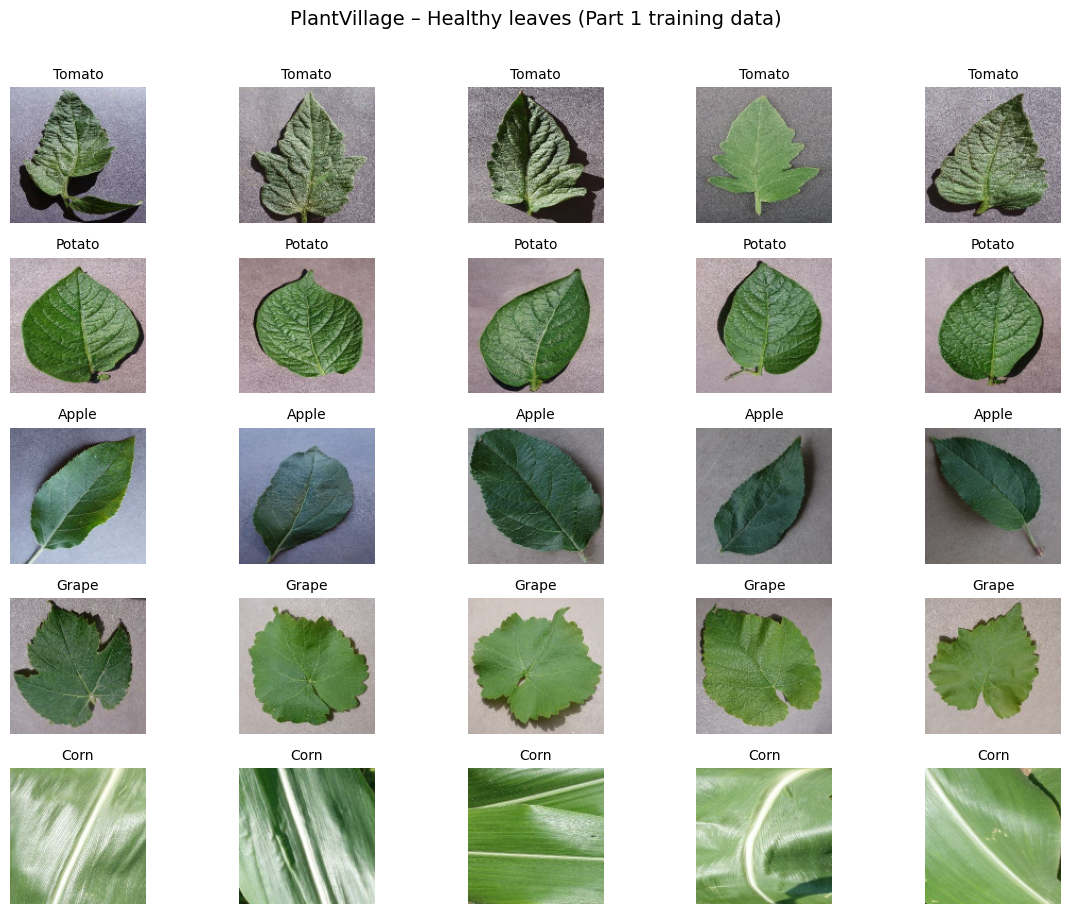

In [11]:
examples = {0: [], 1: [], 2: [], 3: [], 4:[]}
for img, lbl in ds_filtered:
    lbl_int = int(lbl.numpy())
    if len(examples[lbl_int]) < 5:
        examples[lbl_int].append(img.numpy())
    if all(len(v) == 5 for v in examples.values()):
        break

fig, axes = plt.subplots(5, 5, figsize=(12, 9))
fig.suptitle('PlantVillage – Healthy leaves (Part 1 training data)', fontsize=14, y=1.01)

for row, name in enumerate(NEW_CLASS_NAMES):
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(examples[row][col])
        ax.set_title(name, fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

> **Question 1:**  
> Look at the images above. Without using a CNN, what features would *you* use to distinguish tomato, potato, and grape leaves? Note your observations here.
>
> Corn doesnt show borders! It would be a challenge

---
## Step 3 – Create train / validation splits

We use 80% of the data for training and 20% for validation.

In [12]:
total_count = sum(counts.values())
n_train     = int(total_count * 0.8)
n_val       = total_count - n_train

print(f'Training images  : {n_train}')
print(f'Validation images: {n_val}')

# Cache first — scans the filtered dataset once and holds it in RAM.
# For ~1,700 images at 128x128 this is around 250 MB, well within Colab's limit.
ds_cached = ds_filtered.cache()

# Validation: take the LAST n_val images from the cached set (fixed, never shuffled)
ds_val_raw   = ds_cached.skip(n_train)

# Training: take the FIRST n_train images, then shuffle freshly each epoch
ds_train_raw = ds_cached.take(n_train)

ds_train = (
    ds_train_raw
    .shuffle(buffer_size=n_train, seed=42, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_val = (
    ds_val_raw
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print('Data pipelines ready.')

Training images  : 3978
Validation images: 995
Data pipelines ready.


---
## Step 4 – Build the CNN

We build a CNN matching the architecture from the lecture:

```
INPUT (128x128x3)
  |
  |-- CONV (32 filters, 3x3) --> BatchNorm --> ReLU --> MaxPool(2x2)  [output: 64x64x32]
  |-- CONV (64 filters, 3x3) --> BatchNorm --> ReLU --> MaxPool(2x2)  [output: 32x32x64]
  |-- CONV (128 filters,3x3) --> BatchNorm --> ReLU --> MaxPool(2x2)  [output: 16x16x128]
  |
  |-- Flatten
  |-- Dense (128) --> ReLU --> Dropout(0.4)
  +-- Dense (3)   --> Softmax  -->  [Tomato, Potato, Grape]
```

**Recall from the lecture:**
- Each Conv layer uses *shared weights* — the same small filter slides across the whole image
- BatchNorm stabilises training (prevents vanishing/exploding gradients)
- MaxPool halves the spatial size at each block
- The FC head combines all detected features into a final class score

In [13]:
def build_cnn(num_classes=5, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential(name='PlantVillage_CNN')

    # Block 1 -- low-level features: edges, colours, simple textures
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.BatchNormalization(name='bn1'))
    model.add(layers.Activation('relu', name='relu1'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool1'))

    # Block 2 -- mid-level features: corners, curves, repeated patterns
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', name='conv2'))
    model.add(layers.BatchNormalization(name='bn2'))
    model.add(layers.Activation('relu', name='relu2'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool2'))

    # Block 3 -- high-level features: leaf shapes, vein patterns
    model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same', name='conv3'))
    model.add(layers.BatchNormalization(name='bn3'))
    model.add(layers.Activation('relu', name='relu3'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool3'))

    # Classifier head
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(128, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.4, name='dropout'))  # zero out 40% of neurons during training
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

model = build_cnn(num_classes=5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "PlantVillage_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,221 (16.36 MB)

 Trainable params: 4,288,773 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

---
## Step 5 – Compile and train

**Loss:** `sparse_categorical_crossentropy` — standard for multi-class problems with integer labels  
**Optimiser:** Adam (lr = 0.001)  
**Early stopping:** stop if validation loss does not improve for 5 epochs, restore best weights

In [14]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

print('Starting training — a few minutes on GPU ...')
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20,
    callbacks=[early_stop],
    verbose=1,
)

Starting training — a few minutes on GPU ...
Epoch 1/20
    125/Unknown 39s 53ms/step - accuracy: 0.7955 - loss: 4.0329

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 324ms/step - accuracy: 0.8914 - loss: 1.4086 - val_accuracy: 0.2432 - val_loss: 5.1109
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9643 - loss: 0.1193 - val_accuracy: 0.2392 - val_loss: 5.7393
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9693 - loss: 0.1057 - val_accuracy: 0.7286 - val_loss: 1.4322
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9633 - loss: 0.1152 - val_accuracy: 0.7357 - val_loss: 1.2935
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9633 - loss: 0.1421 - val_accuracy: 0.9427 - val_loss: 0.1600
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9771 - loss: 0.0794 - val_accuracy: 0.9920 - val_loss: 0.0306
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9809 - loss: 0.0623 - val_accuracy: 0.9759 - val_loss: 0.1807
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9731 - loss: 0.0869 - val_accuracy: 0.9

---
## Step 6 – Evaluate: Training curves

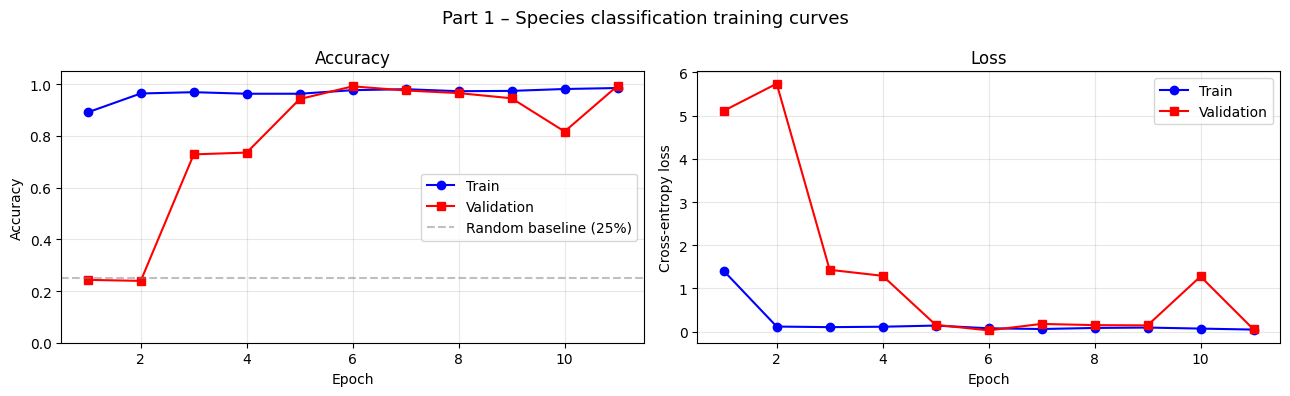

Best validation accuracy: 0.994 (99.4%)


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Part 1 – Species classification training curves', fontsize=13)

epochs_ran = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs_ran, history.history['accuracy'],     'o-', label='Train',             color='blue')
ax1.plot(epochs_ran, history.history['val_accuracy'], 's-', label='Validation',        color='red')
ax1.axhline(1/4, color='grey', linestyle='--', alpha=0.5, label='Random baseline (25%)')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history.history['loss'],     'o-', label='Train',      color='blue')
ax2.plot(epochs_ran, history.history['val_loss'], 's-', label='Validation', color='red')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-entropy loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {best_acc:.3f} ({best_acc*100:.1f}%)')

> **Questions – Interpreting training curves:**  
> 1. Does training accuracy keep climbing while validation accuracy flattens or drops? What does that indicate?
> 2. A random classifier on 4 balanced classes achieves 25%. By how much did your CNN beat this baseline?
> 3. Did early stopping trigger? At which epoch? Why is early stopping useful?

---
## Step 7 – Evaluate: Confusion matrix

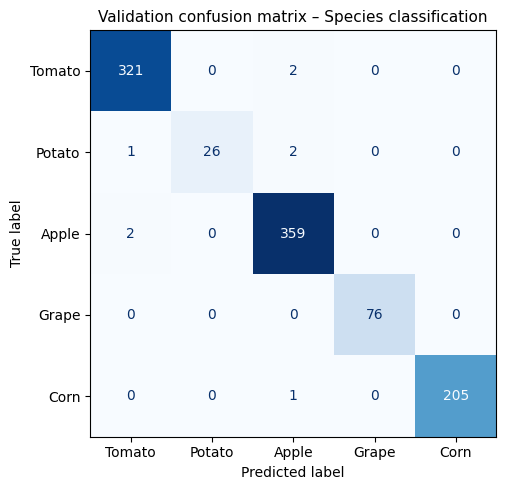


              precision    recall  f1-score   support

      Tomato       0.99      0.99      0.99       323
      Potato       1.00      0.90      0.95        29
       Apple       0.99      0.99      0.99       361
       Grape       1.00      1.00      1.00        76
        Corn       1.00      1.00      1.00       206

    accuracy                           0.99       995
   macro avg       1.00      0.98      0.99       995
weighted avg       0.99      0.99      0.99       995



In [16]:
y_true, y_pred = [], []
for images, labels in ds_val:
    probs = model.predict(images, verbose=0)  # shape: (batch_size, 3)
    preds = np.argmax(probs, axis=1)           # class with highest probability
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=NEW_CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Validation confusion matrix – Species classification', fontsize=11)
plt.tight_layout()
plt.show()

print()
print(classification_report(y_true, y_pred, target_names=NEW_CLASS_NAMES))

> **Questions – Interpreting the confusion matrix:**  
> 1. Which species was classified most accurately?
> 2. Which two species were most often confused with each other? Does that make sense given the leaf images?
> 3. Tomato and potato are botanically related (both *Solanum*). Did the CNN reflect this in its mistakes?

---
## Step 8 – Look at what the model gets wrong

Visualising misclassified images is one of the best ways to understand model behaviour.

Misclassified: 8 / 995 (0.8% error rate)


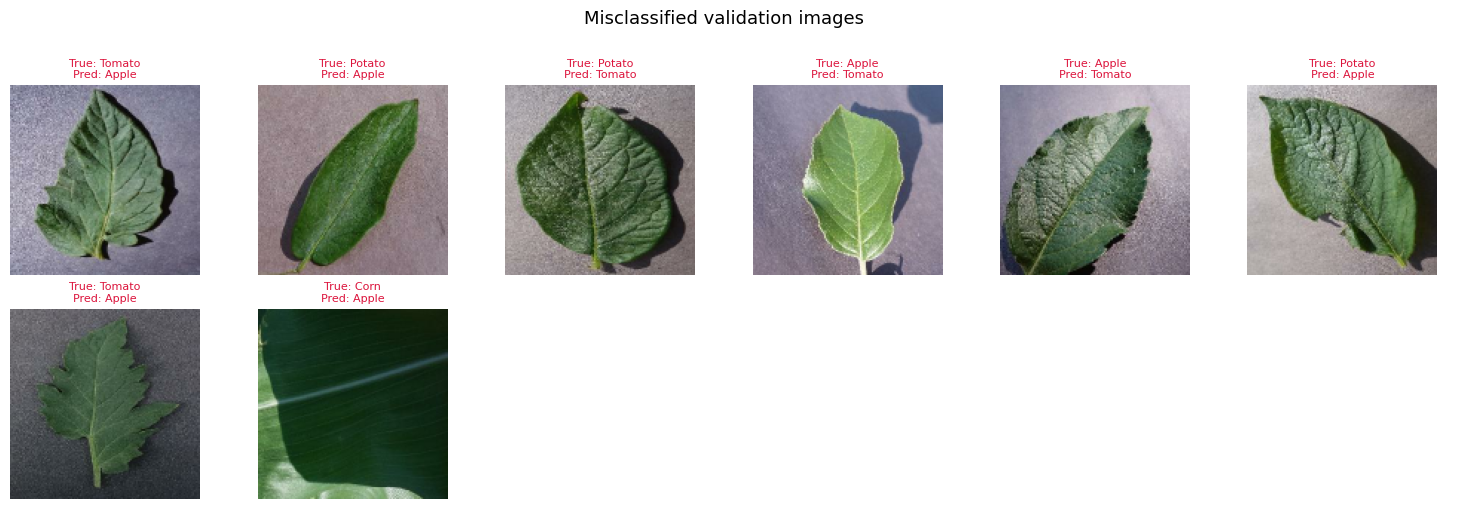

In [17]:
all_images, all_true, all_pred = [], [], []
for images, labels in ds_val:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    all_images.extend(images.numpy())
    all_true.extend(labels.numpy())
    all_pred.extend(preds)

all_images = np.array(all_images)
all_true   = np.array(all_true)
all_pred   = np.array(all_pred)

wrong      = all_true != all_pred
wrong_imgs = all_images[wrong]
wrong_true = all_true[wrong]
wrong_pred = all_pred[wrong]

print(f'Misclassified: {wrong.sum()} / {len(all_true)} ({100*wrong.mean():.1f}% error rate)')

n_show = min(12, len(wrong_imgs))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Misclassified validation images', fontsize=13, y=1.01)

for ax, img, true, pred in zip(
        axes.flat, wrong_imgs[:n_show], wrong_true[:n_show], wrong_pred[:n_show]):
    ax.imshow(img)
    ax.set_title(f'True: {NEW_CLASS_NAMES[true]}\nPred: {NEW_CLASS_NAMES[pred]}',
                 fontsize=8, color='crimson')
    ax.axis('off')
for ax in axes.flat[n_show:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

> **Questions – Misclassified images:**  
> 1. Can you identify the correct species from these images by eye? Are the model's mistakes understandable?
> 2. Do the misclassified images share any common features (lighting, angle, colour)?
> 3. Would a human expert in plant pathology make the same mistakes?

---
## Step 9 – Experiment: Change the architecture

Try at least **one** of the modifications below and note what changes.

| Experiment | What to change |
|------------|----------------|
| A. Fewer layers | Delete conv block 3 entirely |
| B. More filters | Change 32->64, 64->128, 128->256 |
| C. No BatchNorm | Remove all BatchNormalization lines |
| D. No Dropout | Remove the Dropout line |
| E. Larger filters | Change kernel_size=(3,3) to (5,5) everywhere |

In [33]:
def build_cnn_modified(num_classes=5, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Copy of build_cnn() -- make your modification here.
    """
    model = models.Sequential(name='PlantVillage_CNN_Modified')

    # Block 1 -- low-level features: edges, colours, simple textures
    model.add(layers.Conv2D(16, kernel_size=(3, 3), padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.BatchNormalization(name='bn1'))
    model.add(layers.Activation('relu', name='relu1'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool1'))

    # Block 2 -- mid-level features: corners, curves, repeated patterns
    #model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', name='conv2'))
    #model.add(layers.BatchNormalization(name='bn2'))
    #model.add(layers.Activation('relu', name='relu2'))
    #model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool2'))

    # Block 3 -- high-level features: leaf shapes, vein patterns
    #model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same', name='conv3'))
    #model.add(layers.BatchNormalization(name='bn3'))
    #model.add(layers.Activation('relu', name='relu3'))
    #model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool3'))

    # Classifier head
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(16, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.4, name='dropout'))  # zero out 40% of neurons during training
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

model_exp = build_cnn_modified(num_classes=5)
model_exp.summary()

Model: "PlantVillage_CNN_Modified"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 128, 16)   │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 16)             │     1,048,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,049,189 (4.00 MB)

 Trainable params: 1,049,157 (4.00 MB)

 Non-trainable params: 32 (128.00 B)

In [34]:
model_exp.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_exp = model_exp.fit(
    ds_train,
    validation_data=ds_val,
    epochs=30,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],
    verbose=1,
)

print()
print(f"Original model -- best val accuracy: {max(history.history['val_accuracy']):.3f}")
print(f"Modified model -- best val accuracy: {max(history_exp.history['val_accuracy']):.3f}")

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5907 - loss: 1.6008 - val_accuracy: 0.3879 - val_loss: 1.6504
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6825 - loss: 0.9989 - val_accuracy: 0.5688 - val_loss: 1.1774
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7129 - loss: 0.8975 - val_accuracy: 0.5578 - val_loss: 1.1538
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7026 - loss: 0.8900 - val_accuracy: 0.7095 - val_loss: 0.9150
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6631 - loss: 0.9445 - val_accuracy: 0.6683 - val_loss: 0.9285
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6918 - loss: 0.8747 - val_accuracy: 0.5819 - val_loss: 13.0448
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6976 - loss: 0.8503 - val_accuracy: 0.8673 - val_loss: 0.6278
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6938 - loss: 0.9186 - val_accuracy:

> **Questions – Architecture experiment:**  
> 1. Which experiment did you try? What was your hypothesis?
> 2. Did validation accuracy go up or down? By how much?
> 3. Did the total parameter count change?
> 4. Can you explain the result based on what you learned in the lecture?

What I did:

1. Removing conv block 1 and 2 plus reducing to 32 the dense network. I want to damage the acurracy of the model. Effectively it went down to 0.890 from 0.994. The total parameter change to 4,195,525 from 4,289,221. It looks like the dense layer is taking most of the work in both models.
2. Keeping removed conv block 1 and 2 plus reducing the load on the FC layer. I use a exagerated simplistic 4 feature maps and 4 neurons in the dense. The accurracy got to 0.3358 a little bit more than change of 25%.